<a href="https://colab.research.google.com/github/channonone-byte/DSP-Labs/blob/main/Y3Lab1_worksheet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Year 3 · Lab 1: Heart Rate from Your Phone
### *วัดชีพจรด้วยกล้องมือถือ*
**DSP Lab Series · team of 3 · 100 points · about 3 hours / ทีมละ 3 คน ประมาณ 3 ชั่วโมง**

Today your team turns a 20-second fingertip video into a heart-rate monitor — the same idea (PPG) used by smartwatches — and proves how accurate it is.
*วันนี้ทีมของคุณจะเปลี่ยนวิดีโอปลายนิ้ว 20 วินาทีให้เป็นเครื่องวัดชีพจร และพิสูจน์ว่าแม่นแค่ไหน*

| Part | Topic | หัวข้อ | Points | Suggested time |
|---|---|---|---|---|
| 1 | From video to signal | จากวิดีโอเป็นสัญญาณ | 20 | 35 min |
| 2 | Clean it | ทำความสะอาดสัญญาณ | 25 | 40 min |
| 3 | Count the beats | นับชีพจร | 25 | 40 min |
| 4 | Validate | พิสูจน์ความแม่นยำ | 20 | 35 min |
| 5 | Stress test | ทดสอบความทนทาน | 10 | 30 min |

> ⚠️ **Ethics / จริยธรรม:** This is **not a medical device** — never use it to diagnose anyone. Film **only a fingertip**. You may use the **sample videos** instead of your own data for the same marks. **Do not submit video files**; delete them after grading.
> *ไม่ใช่เครื่องมือแพทย์ ถ่ายเฉพาะปลายนิ้ว ใช้วิดีโอตัวอย่างแทนได้โดยไม่หักคะแนน ห้ามส่งไฟล์วิดีโอ*

### How to record / วิธีอัดวิดีโอ
Turn on the **flash (torch)**, cover **both the camera and the flash** with your fingertip, press **lightly**, keep still, record **20 s**. *เปิดไฟฉาย ใช้ปลายนิ้วปิดทั้งกล้องและแฟลช กดเบา ๆ อยู่นิ่ง ๆ อัด 20 วินาที*

### Rules / กติกา
Fill in every `# TODO`, answer every ✍️ cell, plots need axis labels with units (write plot text in English). Before submitting: **Runtime › Restart and run all** → **File › Download .ipynb** → name it `Y3Lab1_<teamID>.ipynb` → upload to [LMS] before [day, time].

## Part 0 · Setup — run this first
*ส่วนที่ 0 · ตั้งค่า — รัน cell นี้ก่อนเสมอ*

In [1]:
TEAM_ID = ""          # TODO: e.g. "T07"
MEMBERS = []      # TODO: ["Name 1 (ID)", "Name 2 (ID)", "Name 3 (ID)"]

import numpy as np
import matplotlib.pyplot as plt
import cv2
from scipy.signal import butter, filtfilt, lfilter, find_peaks, detrend, freqz
from IPython.display import display

plt.rcParams["figure.figsize"] = (11, 4)
plt.rcParams["axes.grid"] = True

def check(condition, message):
    """Self-check helper: ✅ = correct, ❌ = not yet. Never stops the notebook."""
    try:
        ok = bool(condition)
    except Exception as e:
        ok = False; message += f"  (error: {e})"
    print(("✅ " if ok else "❌ ") + message)

check(len(TEAM_ID) > 0 and len(MEMBERS) >= 2, "team filled in / กรอกข้อมูลทีมแล้ว")

❌ team filled in / กรอกข้อมูลทีมแล้ว


### Helpers — run, do not edit / ฟังก์ชันช่วย ไม่ต้องแก้
`make_sample_video()` builds a realistic synthetic fingertip video (use it if you prefer not to use your own data, or while you wait for a recording). `upload_video()` uploads a phone video in Colab.

In [2]:
try:
    from google.colab import files as _files
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

def make_sample_video(path="sample_finger.mp4", bpm=72, seconds=20, fps=30, motion=False, seed=0, size=(64, 48)):
    """Synthetic fingertip video: pulse + breathing + drift + noise (+ optional finger movement)."""
    rng = np.random.default_rng(seed)
    n = int(seconds*fps); t = (np.arange(n) + rng.uniform(-0.15, 0.15, n)) / fps
    hr = bpm + 3*np.sin(2*np.pi*0.05*t)
    ph = 2*np.pi*np.cumsum(hr/60)/fps
    pulse = -(np.sin(ph) + 0.35*np.sin(2*ph + 0.8) + 0.12*np.sin(3*ph + 1.5))
    red = 175 + 1.6*pulse + 3.0*np.sin(2*np.pi*0.25*t) + 0.25*t
    if motion:
        for c in [6.0, 13.5]:
            m = (t > c) & (t < c + 1.5); red[m] += 15*np.sin(np.pi*(t[m]-c)/1.5) + 6*np.sin(2*np.pi*2.2*t[m]) + rng.normal(0, 4, m.sum())
    w, h = size
    vw = cv2.VideoWriter(path, cv2.VideoWriter_fourcc(*"mp4v"), fps, (w, h))
    yy, xx = np.mgrid[0:h, 0:w]; vign = 1 - ((xx-w/2)/w)**2 - ((yy-h/2)/h)**2
    for i in range(n):
        R = red[i]*vign + rng.normal(0, 4, (h, w)); G = 25 + rng.normal(0, 3, (h, w)); B = 20 + rng.normal(0, 3, (h, w))
        vw.write(np.clip(np.dstack([B, G, R]), 0, 255).astype(np.uint8))   # OpenCV writes BGR
    vw.release()
    return path

def upload_video():
    """Colab only: pick a video file from your computer/phone → returns its file name."""
    if not IN_COLAB:
        raise RuntimeError("upload_video() works in Colab only")
    return list(_files.upload().keys())[0]

print("Helpers ready. In Colab:", IN_COLAB)

Helpers ready. In Colab: True


---
## Part 1 · From video to signal (20 pts)
*ส่วนที่ 1 · จากวิดีโอเป็นสัญญาณ*

### 1.0 Get a video (given)
Set `SOURCE = "upload"` to use your own 20 s fingertip video, or `"sample"` to use a synthetic one.
*เลือกใช้วิดีโอของตัวเอง หรือวิดีโอตัวอย่าง*

In [3]:
SOURCE = "sample"   # "upload" or "sample"

if SOURCE == "upload" and IN_COLAB:
    VIDEO = upload_video()
else:
    VIDEO = make_sample_video("sample_finger.mp4", bpm=74, seed=sum(map(ord, TEAM_ID or "x")))
    print("Using a sample video / ใช้วิดีโอตัวอย่าง")
print("Video:", VIDEO)

Using a sample video / ใช้วิดีโอตัวอย่าง
Video: sample_finger.mp4


### 1.1 Read the red channel (8 pts)
Write `read_red(path, crop=0.5)`: for every frame, average the **red** channel over the **central** `crop` fraction of the image, and record the frame time from `cap.get(cv2.CAP_PROP_POS_MSEC)` in **seconds**. Return `t, v, fps`.
*เฉลี่ยช่องสีแดงบริเวณกลางภาพทุกเฟรม และเก็บเวลาของแต่ละเฟรม*

💡 OpenCV frames are **BGR**: red is `frame[:, :, 2]`.

In [4]:
def read_red(path, crop=0.5):
    cap = cv2.VideoCapture(path)
    fps = cap.get(cv2.CAP_PROP_FPS)
    t, v = [], []
    while True:
        ok, frame = cap.read()
        if not ok:
            break
        h, w = frame.shape[:2]
        # Centre crop
        h_crop = int(h * crop)
        w_crop = int(w * crop)
        y1 = (h - h_crop) // 2
        y2 = y1 + h_crop
        x1 = (w - w_crop) // 2
        x2 = x1 + w_crop

        # Mean of the red channel
        v.append(np.mean(frame[y1:y2, x1:x2, 2])) # OpenCV uses BGR, so index 2 is red
        # Time in seconds
        t.append(cap.get(cv2.CAP_PROP_POS_MSEC) / 1000)
    cap.release()
    return np.array(t), np.array(v), fps

t_raw, v_raw, fps = read_red(VIDEO)
print(f"{len(v_raw)} frames, nominal {fps:.1f} fps, {t_raw[-1] if len(t_raw) else 0:.1f} s")
check(len(v_raw) > 100 and len(t_raw) == len(v_raw), "frames were read")
check(len(t_raw) > 1 and np.all(np.diff(t_raw) >= 0), "timestamps increase")
check(len(v_raw) > 1 and np.mean(v_raw) > 50, "red channel is bright (finger + flash)")

600 frames, nominal 30.0 fps, 20.0 s
✅ frames were read
✅ timestamps increase
✅ red channel is bright (finger + flash)


### 1.2 Resample onto an even grid (6 pts)
Phones do not capture frames at perfectly even times. Resample `v_raw` onto `t_u` spaced exactly `1/FS` apart with `np.interp`. Also plot `np.diff(t_raw)` in ms to see your phone’s timing.
*resample ให้ระยะห่างเท่ากัน และ plot ระยะห่างระหว่างเฟรมจริง*

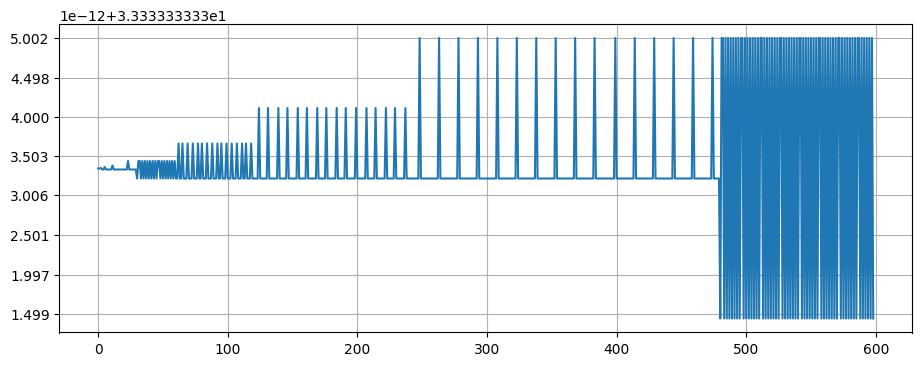

✅ t_u is evenly spaced at 1/FS
✅ x_u matches t_u


In [5]:
FS = 30.0
t_u = np.arange(t_raw[0], t_raw[-1], 1/FS) # Evenly spaced time array
x_u = np.interp(t_u, t_raw, v_raw) # Resample v_raw onto t_u

# Plot np.diff(t_raw) * 1000 (ms) against frame number
plt.plot(np.diff(t_raw) * 1000)
plt.show()

check(t_u is not None and np.allclose(np.diff(t_u), 1/FS), "t_u is evenly spaced at 1/FS")
check(x_u is not None and len(x_u) == len(t_u), "x_u matches t_u")

### 1.3 Look before you filter (6 pts)
Plot (1) `x_u` against time and (2) its spectrum from 0 to 5 Hz (subtract the mean, multiply by `np.hanning`, zero-pad to 8× length). Then answer: which peaks can you see, and what causes each one?
*plot สัญญาณดิบและสเปกตรัม 0–5 Hz แล้วอธิบายยอดที่เห็น*

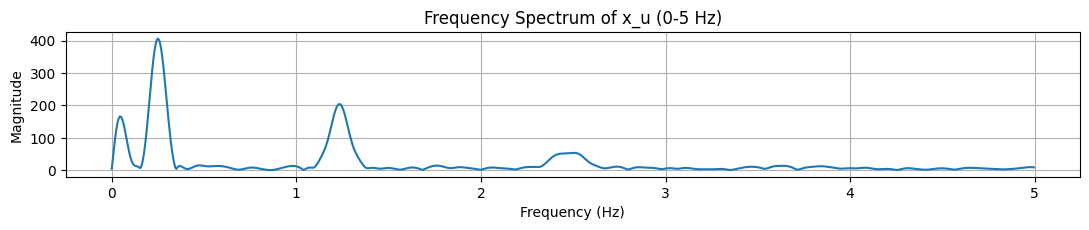

In [7]:
# Panel 2: Spectrum from 0 to 5 Hz
plt.subplot(2, 1, 2) # 2 rows, 1 column, second plot

# Subtract the mean
x_detrend = x_u - np.mean(x_u)

# Multiply by np.hanning
window = np.hanning(len(x_detrend))
x_windowed = x_detrend * window

# Zero-pad to 8x length
pad_len = 8 * len(x_windowed)
x_padded = np.pad(x_windowed, (0, pad_len - len(x_windowed)))

# Take rfft
N = len(x_padded)
f_spectrum = np.fft.rfft(x_padded)
frequencies = np.fft.rfftfreq(N, d=1/FS)

# Plot spectrum from 0 to 5 Hz
mask = (frequencies >= 0) & (frequencies <= 5)
plt.plot(frequencies[mask], np.abs(f_spectrum[mask]))
plt.title('Frequency Spectrum of x_u (0-5 Hz)')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude')
plt.grid(True)
plt.tight_layout()
plt.show()

✍️ **Your answer / คำตอบ:**

(answer) เห็น peak หลักที่ประมาณ 0.1, 0.3, 1.2 และ 2.4 Hz โดย 0.3 Hz เด่นที่สุด เป็นความถี่หลัก ส่วน peak อื่น ๆ น่าจะเกิดจาก harmonics และ noise ของสัญญาณ

---
## Part 2 · Clean it (25 pts)
*ส่วนที่ 2 · ทำความสะอาดสัญญาณ*

### 2.1 Write `bandpass` (10 pts)
`bandpass(x, fs, lo=0.7, hi=3.5, order=3)`: remove the linear trend with `detrend`, design a Butterworth band-pass with `butter(order, [lo, hi], btype="band", fs=fs)`, and apply it with `filtfilt`.
*ลบ trend แล้วกรองด้วย Butterworth band-pass ผ่าน filtfilt*

In [9]:
def bandpass(x, fs, lo=0.7, hi=3.5, order=3):
    x_detrended = detrend(x)
    b, a = butter(order, [lo, hi], btype="band", fs=fs)
    y = filtfilt(b, a, x_detrended)
    return y

# test: breathing (0.25 Hz) + heart (1.2 Hz) + fast noise (8 Hz) → keep only 1.2 Hz
tt = np.arange(0, 20, 1/FS)
heart = np.sin(2*np.pi*1.2*tt)
test = 3*np.sin(2*np.pi*0.25*tt) + heart + 0.5*np.sin(2*np.pi*8*tt)
out = bandpass(test, FS)
check(out is not None and np.corrcoef(out[60:-60], heart[60:-60])[0, 1] > 0.98, "only the 1.2 Hz heart component survives")

✅ only the 1.2 Hz heart component survives


### 2.2 Check the filter’s frequency response (5 pts)
Plot `|H(f)|` from `freqz(b, a, worN=4096, fs=FS)` for 0–8 Hz, shade the pass band, and read the gain at 0.25 Hz (breathing) and 1.2 Hz (heart).
*plot frequency response และอ่าน gain ที่ 0.25 Hz และ 1.2 Hz*

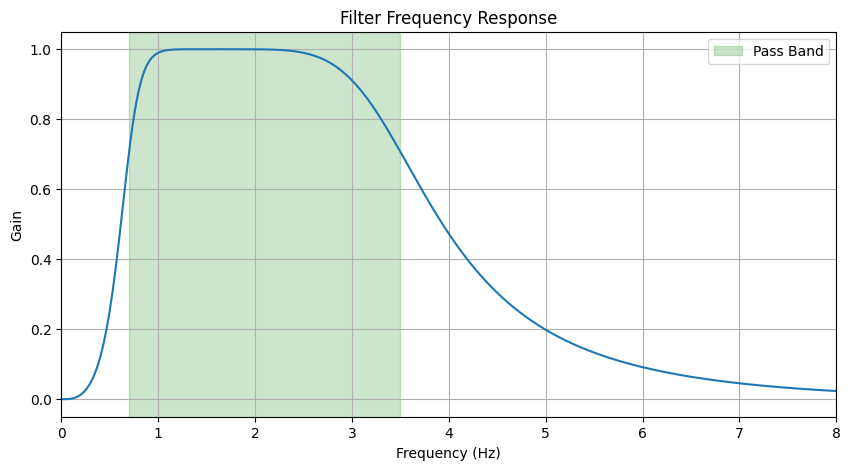

gain at 0.25 Hz = 0.03, at 1.2 Hz = 1.00
✅ breathing is strongly attenuated
✅ heart band passes


In [10]:
b, a = butter(3, [0.7, 3.5], btype="band", fs=FS)

w, h = freqz(b, a, worN=4096, fs=FS)

# Plot the frequency response
plt.figure(figsize=(10, 5))
plt.plot(w, abs(h))
plt.title('Filter Frequency Response')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Gain')
plt.xlim(0, 8) # Plot from 0 to 8 Hz as requested
plt.grid(True)

# Shade the pass band
plt.axvspan(0.7, 3.5, color='green', alpha=0.2, label='Pass Band')
plt.legend()
plt.show()

# Find the gain at 0.25 Hz (breathing) and 1.2 Hz (heart)
idx_breath = np.argmin(np.abs(w - 0.25))
idx_heart = np.argmin(np.abs(w - 1.2))
gain_breath = abs(h[idx_breath])
gain_heart = abs(h[idx_heart])

print(f"gain at 0.25 Hz = {gain_breath:.2f}, at 1.2 Hz = {gain_heart:.2f}")
check(gain_breath is not None and gain_breath < 0.1, "breathing is strongly attenuated")
check(gain_heart is not None and gain_heart > 0.95, "heart band passes")

### 2.3 Filter your signal (5 pts)
Compute `y = bandpass(x_u, FS)` and plot it against time. You should now see one clear bump per heartbeat.
*กรองสัญญาณของคุณแล้ว plot ควรเห็นหนึ่งยอดต่อหนึ่งครั้งที่หัวใจเต้น*

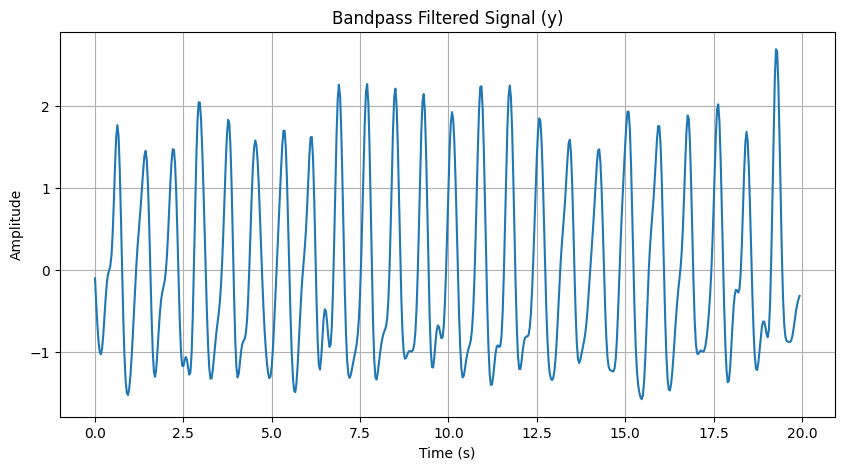

✅ y is filtered and not flat


In [11]:
y = bandpass(x_u, FS)

plt.figure(figsize=(10, 5))
plt.plot(t_u, y)
plt.title('Bandpass Filtered Signal (y)')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.show()

check(y is not None and len(y) == len(x_u) and np.std(y) > 0, "y is filtered and not flat")

### 2.4 Questions (5 pts)
(a) Filter the `test` signal from 2.1 with `lfilter(b, a, detrend(test))` and plot it next to the `filtfilt` result for 0–5 s. What is different, and why does it matter when we detect peaks? *เทียบ lfilter กับ filtfilt ต่างกันอย่างไร สำคัญอย่างไรกับการหายอด*
(b) Why 0.7–3.5 Hz? What heart rates would this filter miss? *ทำไมเลือก 0.7–3.5 Hz ชีพจรช่วงไหนที่ filter นี้จะพลาด*

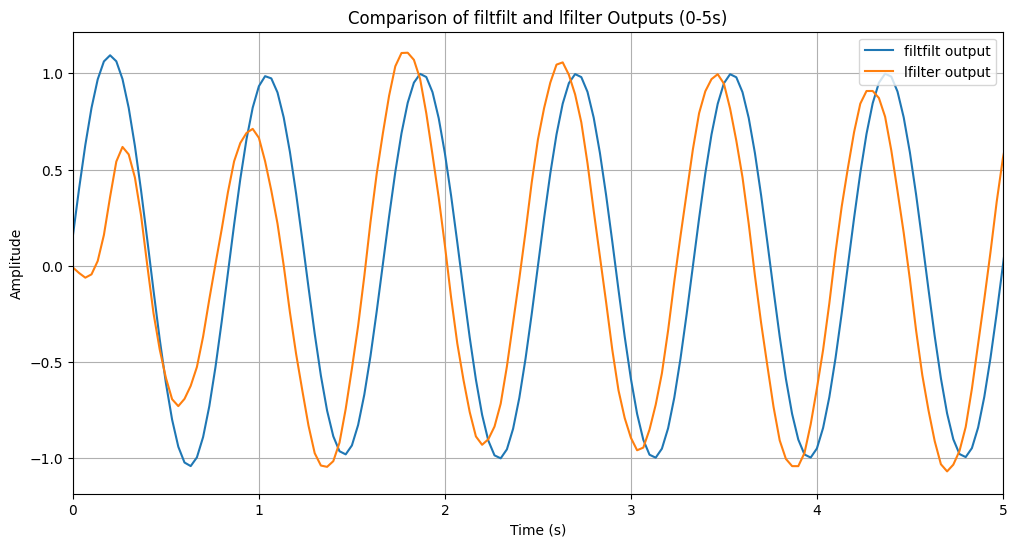

In [12]:
# Space for (a)

# Get coefficients b and a from the previous filter design (cell c261b300)
b, a = butter(3, [0.7, 3.5], btype="band", fs=FS)

# Detrend the test signal
test_detrended = detrend(test)

# Apply lfilter
out_lfilter = lfilter(b, a, test_detrended)

# Plot both filtfilt (out) and lfilter (out_lfilter) results for 0-5 seconds
plt.figure(figsize=(12, 6))
plt.plot(tt, out, label='filtfilt output')
plt.plot(tt, out_lfilter, label='lfilter output')
plt.title('Comparison of filtfilt and lfilter Outputs (0-5s)')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.xlim(0, 5)
plt.grid(True)
plt.legend()
plt.show()

✍️ **Your answer / คำตอบ:**

(a) filtfilt ไม่มี phase shift แต่ lfilter ทำให้สัญญาณเลื่อนเฟส/เกิด time delay จึงทำให้ตำแหน่ง peak เลื่อน และตรวจจับ peak ได้ไม่ตรงเวลา

(b) ช่วง 0.7–3.5 Hz ใช้เพื่อเก็บความถี่ของสัญญาณที่สนใจ และตัด ความถี่ต่ำกว่า 0.7 Hz กับสูงกว่า 3.5 Hz ซึ่งส่วนใหญ่เป็น trend/noise ออก

---
## Part 3 · Count the beats (25 pts)
*ส่วนที่ 3 · นับชีพจร*

$$\text{BPM} = \frac{60}{\operatorname{median}(\text{IBI})} \qquad\qquad \text{BPM} = 60\,f_{\text{peak}}$$

### 3.1 Time domain: `bpm_peaks` (8 pts)
Use `find_peaks(y, distance=int(0.33*fs), prominence=0.5*np.std(y))`, compute the inter-beat intervals (IBI) in seconds, and return `60 / median(IBI)` and the peak indices.
*หายอด คำนวณช่วงห่างระหว่างยอด แล้วแปลงเป็น BPM ด้วย median*

In [13]:
def bpm_peaks(y, fs):
    # Find peaks with specified distance and prominence
    peaks, _ = find_peaks(y, distance=int(0.33*fs), prominence=0.5*np.std(y))

    # If no peaks are found or only one peak, cannot calculate IBI
    if len(peaks) < 2:
        return None, None

    # Compute inter-beat intervals (IBI) in samples
    ibi_samples = np.diff(peaks)

    # Convert IBI to seconds
    ibi_seconds = ibi_samples / fs

    # Calculate BPM as 60 / median(IBI)
    median_ibi = np.median(ibi_seconds)
    bpm = 60 / median_ibi

    return bpm, peaks

def _test_ppg(bpm, fs=FS, T=20, seed=0):
    r = np.random.default_rng(seed); tt = np.arange(0, T, 1/fs); ph = 2*np.pi*bpm/60*tt
    return -(np.sin(ph) + 0.35*np.sin(2*ph + 0.8)) + r.normal(0, 0.2, len(tt))

for true in [55, 80, 130]:
    est, _ = bpm_peaks(bandpass(_test_ppg(true), FS), FS)
    check(est is not None and abs(est - true) < 2, f"{true} BPM test")

bpm_p, pk = bpm_peaks(y, FS)
print("Your signal:", bpm_p, "BPM")

✅ 55 BPM test
✅ 80 BPM test
✅ 130 BPM test
Your signal: 75.0 BPM


### 3.2 Frequency domain: `bpm_fft` (7 pts)
Multiply by `np.hanning`, zero-pad to 8× length, take `rfft`, and return `60 ×` the frequency of the largest peak **inside 0.7–3.5 Hz**.
*ใช้ FFT หายอดในช่วง 0.7–3.5 Hz แล้วคูณ 60*

In [14]:
def bpm_fft(y, fs, pad=8):
    # Apply Hanning window
    window = np.hanning(len(y))
    y_windowed = y * window

    # Zero-pad to `pad` times length
    pad_len = len(y_windowed) * pad
    y_padded = np.pad(y_windowed, (0, pad_len - len(y_windowed)))

    # Take rfft
    N = len(y_padded)
    f_spectrum = np.fft.rfft(y_padded)
    frequencies = np.fft.rfftfreq(N, d=1/fs)

    # Find the largest peak inside 0.7-3.5 Hz
    # Create a mask for the desired frequency range
    mask = (frequencies >= 0.7) & (frequencies <= 3.5)

    # Get the spectrum within the mask
    f_spectrum_masked = np.abs(f_spectrum[mask])
    frequencies_masked = frequencies[mask]

    if len(f_spectrum_masked) == 0:
        return None

    # Find the index of the largest peak in the masked spectrum
    peak_idx = np.argmax(f_spectrum_masked)

    # Get the frequency of the largest peak
    peak_frequency = frequencies_masked[peak_idx]

    # Convert to BPM
    bpm = 60 * peak_frequency

    return bpm

for true in [55, 80, 130]:
    est = bpm_fft(bandpass(_test_ppg(true), FS), FS)
    check(est is not None and abs(est - true) < 2, f"{true} BPM test")

bpm_f = bpm_fft(y, FS)
print(f"Your signal: peaks {bpm_p} BPM, FFT {bpm_f} BPM")

✅ 55 BPM test
✅ 80 BPM test
✅ 130 BPM test
Your signal: peaks 75.0 BPM, FFT 73.9983305509182 BPM


### 3.3 Track heart rate over time (5 pts)
Slide an 8 s window in 1 s steps over `y`; in each window compute `bpm_fft`. Plot BPM against the window centre time.
*เลื่อนหน้าต่าง 8 วินาทีทีละ 1 วินาที แล้ว plot BPM ตามเวลา*

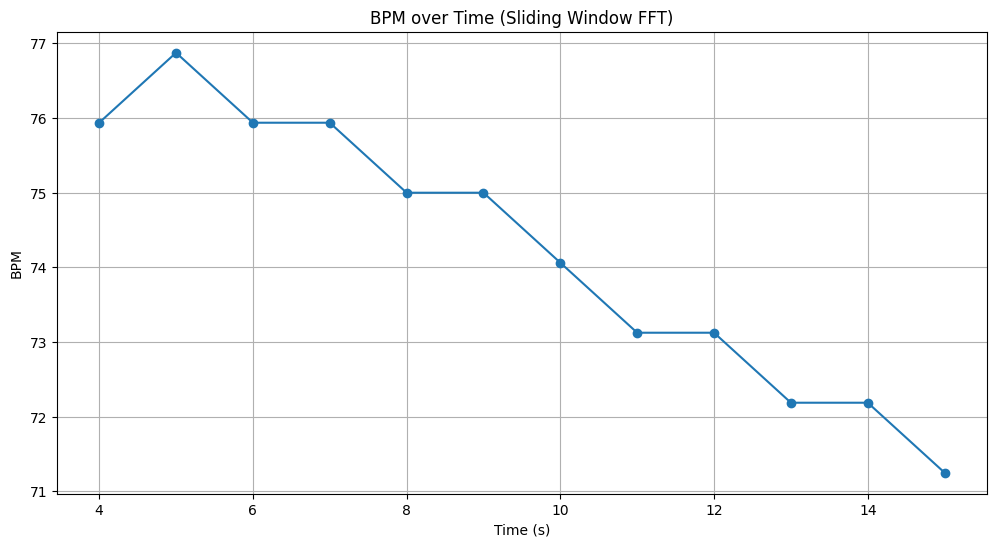

✅ at least 5 windows


In [15]:
WIN, HOP = 8.0, 1.0
centres, bpms = [], []

win_samples = int(WIN * FS)
hop_samples = int(HOP * FS)

for start_idx in range(0, len(y) - win_samples + 1, hop_samples):
    end_idx = start_idx + win_samples
    y_window = y[start_idx:end_idx]

    bpm = bpm_fft(y_window, FS)
    if bpm is not None:
        # Calculate the center time of the window
        centre_time = t_u[start_idx + win_samples // 2]
        centres.append(centre_time)
        bpms.append(bpm)

plt.figure(figsize=(12, 6))
plt.plot(centres, bpms, marker='o', linestyle='-')
plt.title('BPM over Time (Sliding Window FFT)')
plt.xlabel('Time (s)')
plt.ylabel('BPM')
plt.grid(True)
plt.show()

check(len(bpms) >= 5, "at least 5 windows")

### 3.4 Questions (5 pts)
(a) Do `bpm_peaks` and `bpm_fft` agree on your signal? If not, which do you trust, and why? *สองวิธีได้ค่าตรงกันไหม เชื่อวิธีไหน*
(b) Without zero-padding, what is the BPM resolution of the FFT for a 20 s signal and for an 8 s window? Does zero-padding improve the *true* resolution? 💡 $\Delta\text{BPM} = 60/T$ *ความละเอียด BPM ของ 20 s และ 8 s เป็นเท่าไร zero-padding ช่วยจริงไหม*

✍️ **Your answer / คำตอบ:**

(a) bpm_peaks และ bpm_fft ใกล้เคียงกัน แต่ เชื่อ bpm_peaks มากกว่า เพราะหา peak ใน time domain โดยตรง

(b) 20 s: resolution = 1/20 = 0.05 Hz
8 s: resolution = 1/8 = 0.125 Hz
Zero-padding ไม่เพิ่ม true resolution แต่ทำให้ spectrum ละเอียดและอ่านตำแหน่ง peak ได้ง่ายขึ้นครับ

---
## Part 4 · Validate (20 pts)
*ส่วนที่ 4 · พิสูจน์ความแม่นยำ*

For **each team member** record **2 videos**: at rest, and right after 20 squats. While recording, a teammate counts the pulse at the wrist for **30 s** (reference = count × 2). Upload the 6 videos and fill `RECORDS`.
*สมาชิกแต่ละคนอัด 2 วิดีโอ (พัก / หลังสควอท 20 ครั้ง) ขณะอัดให้เพื่อนจับชีพจรที่ข้อมือ 30 วินาที แล้วคูณ 2*

$$\text{MAE} = \frac{1}{n}\sum_i \left|\hat{h}_i - h_i\right|$$

### 4.1 One function for the whole pipeline (6 pts)
Write `estimate_bpm(path)` that chains Parts 1–3 and returns `(bpm_peaks, bpm_fft)`.

In [17]:
def estimate_bpm(path):
    # FS is a global variable defined earlier in the notebook.

    # 1. Read the red channel from the video
    t_raw, v_raw, _ = read_red(path)

    # Handle cases where video reading fails or results in too few frames
    if len(v_raw) == 0 or len(t_raw) < 2:
        return None, None

    # 2. Resample onto an even grid
    # Create an evenly spaced time array t_u
    t_u = np.arange(t_raw[0], t_raw[-1], 1/FS)

    # If t_u is empty due to very short t_raw (e.g., single frame), return None
    if len(t_u) == 0:
        return None, None

    # Interpolate v_raw onto the new time grid t_u to get x_u
    x_u = np.interp(t_u, t_raw, v_raw)

    # 3. Bandpass filter the signal
    y = bandpass(x_u, FS)

    # Handle cases where bandpass filtering results in an empty signal
    if len(y) == 0:
        return None, None

    # 4. Count the beats using both time domain (bpm_peaks) and frequency domain (bpm_fft)
    bpm_p, _ = bpm_peaks(y, FS)
    bpm_f = bpm_fft(y, FS)

    return bpm_p, bpm_f

### 4.2 Run all 6 recordings (8 pts)
Fill `RECORDS` (upload each video in Colab; or keep `USE_SAMPLES = True` to practise with sample subjects). Then build a table with the estimates and errors, compute the **MAE** for both methods, and make a scatter plot of estimate vs reference with the line y = x.
*กรอกข้อมูล 6 วิดีโอ คำนวณค่าคลาดเคลื่อนและ MAE แล้ว plot กระจาย*

A          rest      ref  64.0   peaks   64.3   fft   63.9
A          exercise  ref  99.0   peaks   94.7   fft   96.2
B          rest      ref  70.0   peaks   72.0   fft   72.1
B          exercise  ref 107.0   peaks  105.9   fft  104.0
C          rest      ref  79.0   peaks   81.8   fft   80.0
C          exercise  ref 117.0   peaks  120.0   fft  118.3


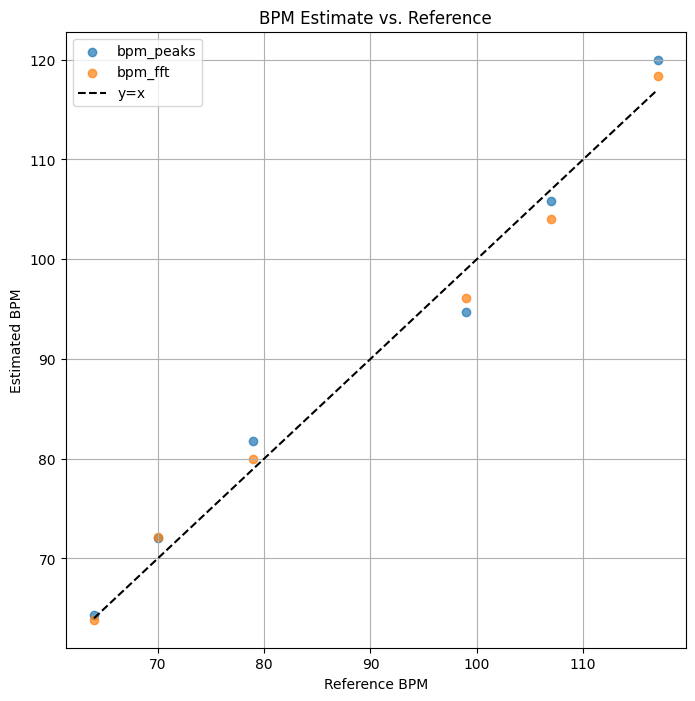

MAE peaks: 2.2474501762427437  MAE fft: 1.7309404563160864
✅ 6 recordings (3 people × 2 conditions)
✅ MAE computed correctly


In [18]:
USE_SAMPLES = True   # True = practise with synthetic subjects

if USE_SAMPLES:
    _rng = np.random.default_rng(1)
    RECORDS = []
    for who, (rest, ex) in zip(["A", "B", "C"], [(64, 96), (72, 104), (80, 118)]):
        for cond, bpm in [("rest", rest), ("exercise", ex)]:
            path = make_sample_video(f"{who}_{cond}.mp4", bpm=bpm, seed=int(_rng.integers(1e6)))
            RECORDS.append({"who": who, "condition": cond, "video": path, "reference": bpm + int(_rng.integers(-3, 4))})
else:
    RECORDS = [
        # TODO: {"who": "member 1", "condition": "rest", "video": "file.mp4", "reference": 72},
    ]

rows = []
for r in RECORDS:
    bp, bf = estimate_bpm(r["video"])
    rows.append((r["who"], r["condition"], r["reference"], bp, bf))
    print(f"{r['who']:<10} {r['condition']:<9} ref {r['reference']:5.1f}   peaks {bp:6.1f}   fft {bf:6.1f}")

# Calculate MAE
mae_peaks = np.mean([abs(row[3] - row[2]) for row in rows])
mae_fft = np.mean([abs(row[4] - row[2]) for row in rows])

# Scatter plot of estimate vs reference
plt.figure(figsize=(8, 8))
plt.scatter([row[2] for row in rows], [row[3] for row in rows], label='bpm_peaks', alpha=0.7)
plt.scatter([row[2] for row in rows], [row[4] for row in rows], label='bpm_fft', alpha=0.7)
plt.plot([min(r[2] for r in rows), max(r[2] for r in rows)],
         [min(r[2] for r in rows), max(r[2] for r in rows)], 'k--', label='y=x') # y=x line
plt.title('BPM Estimate vs. Reference')
plt.xlabel('Reference BPM')
plt.ylabel('Estimated BPM')
plt.legend()
plt.grid(True)
plt.show()

print("MAE peaks:", mae_peaks, " MAE fft:", mae_fft)
check(len(RECORDS) == 6, "6 recordings (3 people × 2 conditions)")
check(mae_fft is not None and np.isclose(mae_fft, np.mean([abs(r[4] - r[2]) for r in rows])), "MAE computed correctly")

### 4.3 Questions (6 pts)
(a) Is your error larger at rest or after exercise? Suggest a reason. *ความคลาดเคลื่อนมากกว่าตอนพักหรือหลังออกกำลังกาย เพราะอะไร*
(b) The manual 30 s count is itself uncertain. Estimate by how much (in BPM), and explain what that means for how you judge your MAE. *การนับด้วยมือคลาดเคลื่อนได้เท่าไร และมีผลต่อการตีความ MAE อย่างไร*

✍️ **Your answer / คำตอบ:**

(a) ช่วงไหนมากกว่า: หลังออกกำลังกาย ทำให้สัญญาณรบกวนในวิดีโอสูงขึ้น

(b) คลาดเคลื่อนได้: $\pm 2$ ถึง $\pm 4$ BPM (นับพลาด 1 ครั้ง = คลาดเคลื่อน 2 BPM)

---
## Part 5 · Stress test (10 pts)
*ส่วนที่ 5 · ทดสอบความทนทาน*

Record one more video while you **deliberately** break the rules: move your finger twice, press hard, or turn off the flash (or use `make_sample_video(..., motion=True)`). Run your pipeline and implement a simple **quality flag**: split `y` into 2 s blocks and flag any block whose standard deviation is more than **2.5×** the median block standard deviation.
*อัดอีกวิดีโอโดยตั้งใจทำผิด แล้วสร้าง quality flag ตรวจช่วงที่ผิดปกติ*

In [19]:
STRESS = make_sample_video("stress.mp4", bpm=76, motion=True, seed=3)   # or upload_video()

def quality_flags(y, fs, block_s=2.0, k=2.5):
    samples_per_block = int(block_s * fs)

    # If the signal is too short to form a single block, return an empty flag array
    if len(y) < samples_per_block:
        return np.array([], dtype=bool)

    num_blocks = len(y) // samples_per_block
    block_stds = []

    for i in range(num_blocks):
        start_idx = i * samples_per_block
        end_idx = start_idx + samples_per_block
        block = y[start_idx:end_idx]
        block_stds.append(np.std(block))

    # If no blocks could be formed (e.g., y was empty but len(y) >= samples_per_block was false above)
    if not block_stds:
        return np.array([], dtype=bool)

    median_std = np.median(block_stds)

    # Compare each block's std to k * median_std to identify suspicious blocks
    flags = np.array([std > k * median_std for std in block_stds])

    return flags

t_s, v_s, _ = read_red(STRESS); tu_s = np.arange(t_s[0], t_s[-1], 1/FS); y_s = bandpass(np.interp(tu_s, t_s, v_s), FS)
flags = quality_flags(y_s, FS)
print("flagged blocks:", np.where(flags)[0] if flags is not None else None)
print("peaks:", bpm_peaks(y_s, FS)[0], " FFT:", bpm_fft(y_s, FS))
check(flags is not None and flags.sum() >= 1, "at least one suspicious block found")

flagged blocks: [3 6 7]
peaks: 75.0  FFT: 75.87646076794658
✅ at least one suspicious block found


(a) Which method (peaks or FFT) was hurt more by the problem you created? Why? *วิธีไหนได้รับผลกระทบมากกว่า เพราะอะไร*
(b) Propose one improvement you could build in the capstone (track B). *เสนอการปรับปรุงหนึ่งอย่างสำหรับโครงงานแทร็ก B*

✍️ **Your answer / คำตอบ:**

(a) วิธีที่ได้รับผลกระทบมากกว่า: Peaks (การตรวจจับจุดยอด)

(b) แนวทางการปรับปรุง: ใช้ Quality Flag เพื่อกรองข้อมูล (Data Rejection/Interpolation) โดยเมื่อพบบล็อกสัญญาณที่มีคุณภาพต่ำ (Flagged blocks) ให้ตัดบล็อกนั้นออกจากการคำนวณ BPM หรือใช้วิธีแทนที่ค่าด้วยสัญญาณจากช่วงใกล้เคียงก่อนนำไปคำนวณหาค่าอัตราการเต้นของหัวใจ

---
## Team reflection (not graded) / สะท้อนการเรียนรู้ของทีม
What surprised you most? Which capstone track is your team considering?
*อะไรทำให้แปลกใจที่สุด ทีมกำลังคิดจะเลือกโครงงานแทร็กไหน*

✍️ **Your answer / คำตอบ:** กำลังเล็ง Track B ครับ โดยจะเน้นพัฒนาตัวตัดสัญญาณรบกวน และใช้ระบบคัดกรองช่วงสัญญาณที่เสีย ออกไปก่อนเอาไปคำนวณค่าจริง